In [1]:
import tensorflow as tf
import numpy as np, pandas as pd, cv2, time
from pathlib import Path
import os
import matplotlib.pyplot as plt
from scipy.optimize import linear_sum_assignment

os.environ['TF_CUDNN_USE_AUTOTUNE']       = '0'
os.environ['TF_XLA_FLAGS']               = '--tf_xla_auto_jit=0'
os.environ['TF_DISABLE_MKL']             = '1'
os.environ['CUDA_DEVICE_MAX_CONNECTIONS']= '1'
tf.config.optimizer.set_jit(False)

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    tf.config.experimental.set_memory_growth(gpus[0], True)
    print(f'GPU: {gpus[0].name}')
else:
    print('WARNING: No GPU found')

I0000 00:00:1779946659.852153   23888 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1779946659.951560   23888 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI AVX_VNNI_INT8 AVX_NE_CONVERT FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1779946661.198595   23888 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


GPU: /physical_device:GPU:0


W0000 00:00:1779946662.915017   23888 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.


In [3]:
DATA_ROOT = Path('/home/krish/vein_detection_task_3_training')
VIDEO_DIR = DATA_ROOT / 'Data/1-Videos'
OUT_DIR   = DATA_ROOT / 'output/tracking'
PLOT_DIR  = OUT_DIR / 'plots'
OUT_DIR.mkdir(parents=True, exist_ok=True)
PLOT_DIR.mkdir(parents=True, exist_ok=True)

IMG_SIZE = 256
MEAN_NP  = np.array([0.485, 0.456, 0.406], np.float32)
STD_NP   = np.array([0.229, 0.224, 0.225], np.float32)

VEIN_CKPT = DATA_ROOT / 'output/vein/checkpoints/unet_resnet50_vein_best.keras'
model = tf.keras.models.load_model(str(VEIN_CKPT), compile=False)
print(f'Model loaded: {VEIN_CKPT.name}')

exts = ['*.mp4', '*.MP4', '*.avi', '*.AVI']
videos = sorted({p for ext in exts for p in VIDEO_DIR.glob(ext)})
print(f'Videos found: {len(videos)}')
for v in videos:
    print(f'  {v.name}')


Model loaded: unet_resnet50_vein_best.keras
Videos found: 5
  202207111318_38-Perf.mp4
  202207191643_00-Moving.mp4
  202207221607_52-Long2.mp4
  Knee-Ankle-Seg1.MP4
  sample_data.mp4


In [7]:
def preprocess_frame(bgr):
    rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB).astype(np.float32) / 255.
    resized = cv2.resize(rgb, (IMG_SIZE, IMG_SIZE))
    return ((resized - MEAN_NP) / STD_NP)[None]

def predict_mask_old(frame_bgr):
    pred = model.predict(preprocess_frame(frame_bgr), verbose=0)[0]
    return np.argmax(pred, -1).astype(np.uint8)

def predict_mask(frame_bgr):
    inp  = preprocess_frame(frame_bgr)
    pred = model(inp, training=False).numpy()[0]
    return np.argmax(pred, -1).astype(np.uint8)

def extract_detections(mask, min_area=50):
    n, labels, stats, centroids = cv2.connectedComponentsWithStats(mask, connectivity=8)
    dets = []
    for i in range(1, n):
        area = stats[i, cv2.CC_STAT_AREA]
        if area < min_area:
            continue
        x = stats[i, cv2.CC_STAT_LEFT]
        y = stats[i, cv2.CC_STAT_TOP]
        w = stats[i, cv2.CC_STAT_WIDTH]
        h = stats[i, cv2.CC_STAT_HEIGHT]
        dets.append({
            'bbox': (x, y, w, h),
            'centroid': (float(centroids[i][0]), float(centroids[i][1])),
            'area': int(area),
        })
    return dets

def bbox_iou(b1, b2):
    x1, y1, w1, h1 = b1
    x2, y2, w2, h2 = b2
    ix = max(0, min(x1+w1, x2+w2) - max(x1, x2))
    iy = max(0, min(y1+h1, y2+h2) - max(y1, y2))
    inter = ix * iy
    return inter / (w1*h1 + w2*h2 - inter + 1e-6)

def match_detections(prev_dets, curr_dets, iou_threshold=0.2):
    if not prev_dets or not curr_dets:
        return [], list(range(len(curr_dets)))
    cost = np.array([[1. - bbox_iou(p['bbox'], c['bbox'])
                      for c in curr_dets] for p in prev_dets], dtype=np.float32)
    rows, cols = linear_sum_assignment(cost)
    matches, matched_curr = [], set()
    for r, c in zip(rows, cols):
        if cost[r, c] < (1. - iou_threshold):
            matches.append((r, c))
            matched_curr.add(c)
    unmatched = [j for j in range(len(curr_dets)) if j not in matched_curr]
    return matches, unmatched

In [14]:
class VeinTracker:
    def __init__(self, max_lost=5):
        self.tracks  = {}
        self.next_id = 0
        self.max_lost = max_lost

    def update(self, detections, frame_idx):
        active_ids = sorted(self.tracks.keys())
        prev_dets  = [self.tracks[tid]['last_det'] for tid in active_ids]

        matches, unmatched_curr = match_detections(prev_dets, detections)
        matched_prev = {p for p, _ in matches}

        for p_idx, c_idx in matches:
            tid = active_ids[p_idx]
            self.tracks[tid].update({
                'last_det': detections[c_idx],
                'lost': 0,
                'age': self.tracks[tid]['age'] + 1,
            })

        for i, tid in enumerate(active_ids):
            if i not in matched_prev:
                self.tracks[tid]['lost'] += 1
        self.tracks = {tid: t for tid, t in self.tracks.items()
                       if t['lost'] <= self.max_lost}

        for c_idx in unmatched_curr:
            self.tracks[self.next_id] = {
                'last_det': detections[c_idx],
                'lost': 0,
                'age': 1,
            }
            self.next_id += 1

        records = []
        for tid, t in self.tracks.items():
            if t['lost'] == 0:
                det = t['last_det']
                x, y, w, h = det['bbox']
                cx, cy = det['centroid']
                records.append({
                    'frame_idx': frame_idx, 'track_id': tid,
                    'cx': round(cx, 2),    'cy': round(cy, 2),
                    'x': x, 'y': y, 'w': w, 'h': h,
                    'area': det['area'],   'age': t['age'],
                })
        return records


def process_video_old(video_path, min_det_area=50, max_lost=5):
    cap     = cv2.VideoCapture(str(video_path))
    tracker = VeinTracker(max_lost=max_lost)
    records = []
    frame_idx = 0
    while True:
        ret, frame = cap.read()
        if not ret:
            break
        mask = predict_mask(frame)
        dets = extract_detections(mask, min_area=min_det_area)
        for r in tracker.update(dets, frame_idx):
            r['video'] = video_path.stem
            records.append(r)
        frame_idx += 1
    cap.release()
    return pd.DataFrame(records), frame_idx

def process_video_v1(video_path, min_det_area=50, max_lost=5, target_fps=5):
    cap     = cv2.VideoCapture(str(video_path))
    src_fps = cap.get(cv2.CAP_PROP_FPS) or 25
    skip    = max(1, round(src_fps / target_fps))
    total   = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    print(f'  {video_path.name}: {src_fps:.1f}fps src → sample every {skip} frames (~{total//skip} frames)')

    tracker  = VeinTracker(max_lost=max_lost)
    records  = []
    raw_idx  = 0   # actual frame counter in file
    proc_idx = 0   # sampled frame index

    while True:
        ret, frame = cap.read()
        if not ret:
            break
        if raw_idx % skip == 0:
            mask = predict_mask(frame)
            dets = extract_detections(mask, min_area=min_det_area)
            for r in tracker.update(dets, proc_idx):
                r['video'] = video_path.stem
                records.append(r)
            proc_idx += 1
        raw_idx += 1

    cap.release()
    return pd.DataFrame(records), proc_idx

def process_video(video_path, min_det_area=50, max_lost=5, target_fps=5):
    cap     = cv2.VideoCapture(str(video_path))
    src_fps = cap.get(cv2.CAP_PROP_FPS) or 25
    skip    = max(1, round(src_fps / target_fps))
    total   = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    print(f'  {video_path.name}: {src_fps:.1f}fps → every {skip} frames (~{total//skip} frames)')

    tracker  = VeinTracker(max_lost=max_lost)
    records  = []
    raw_idx  = 0
    proc_idx = 0

    while True:
        ret, frame = cap.read()
        if not ret:
            break
        if raw_idx % skip == 0:
            mask = predict_mask(frame)
            dets = extract_detections(mask, min_area=min_det_area)
            for r in tracker.update(dets, proc_idx):
                r['video']         = video_path.stem
                r['raw_frame_idx'] = raw_idx
                records.append(r)
            proc_idx += 1
        raw_idx += 1

    cap.release()
    return pd.DataFrame(records), proc_idx

In [15]:
all_dfs, summary = [], []

for vp in sorted(videos):
    t0 = time.time()
    df, n_frames = process_video(vp)
    elapsed = time.time() - t0
    n_tracks = df['track_id'].nunique() if len(df) else 0
    all_dfs.append(df)
    summary.append({'video': vp.stem, 'n_frames': n_frames,
                    'n_tracks': n_tracks, 'elapsed_s': round(elapsed, 1)})
    print(f'{vp.stem}: {n_frames} frames, {n_tracks} tracks, {elapsed:.1f}s')

tracks_df  = pd.concat(all_dfs, ignore_index=True) if all_dfs else pd.DataFrame()
summary_df = pd.DataFrame(summary)
tracks_df.to_csv(OUT_DIR / 'vein_tracks.csv',      index=False)
summary_df.to_csv(OUT_DIR / 'tracking_summary.csv', index=False)
print(f'\nSaved {len(tracks_df)} track records across {len(videos)} videos')

  202207111318_38-Perf.mp4: 59.9fps → every 12 frames (~40 frames)
202207111318_38-Perf: 41 frames, 29 tracks, 2.4s
  202207191643_00-Moving.mp4: 59.9fps → every 12 frames (~122 frames)
202207191643_00-Moving: 123 frames, 16 tracks, 16.9s
  202207221607_52-Long2.mp4: 59.9fps → every 12 frames (~10 frames)
202207221607_52-Long2: 10 frames, 0 tracks, 1.3s
  Knee-Ankle-Seg1.MP4: 59.9fps → every 12 frames (~70 frames)
Knee-Ankle-Seg1: 71 frames, 7 tracks, 10.1s
  sample_data.mp4: 59.9fps → every 12 frames (~79 frames)
sample_data: 80 frames, 31 tracks, 8.2s

Saved 339 track records across 5 videos


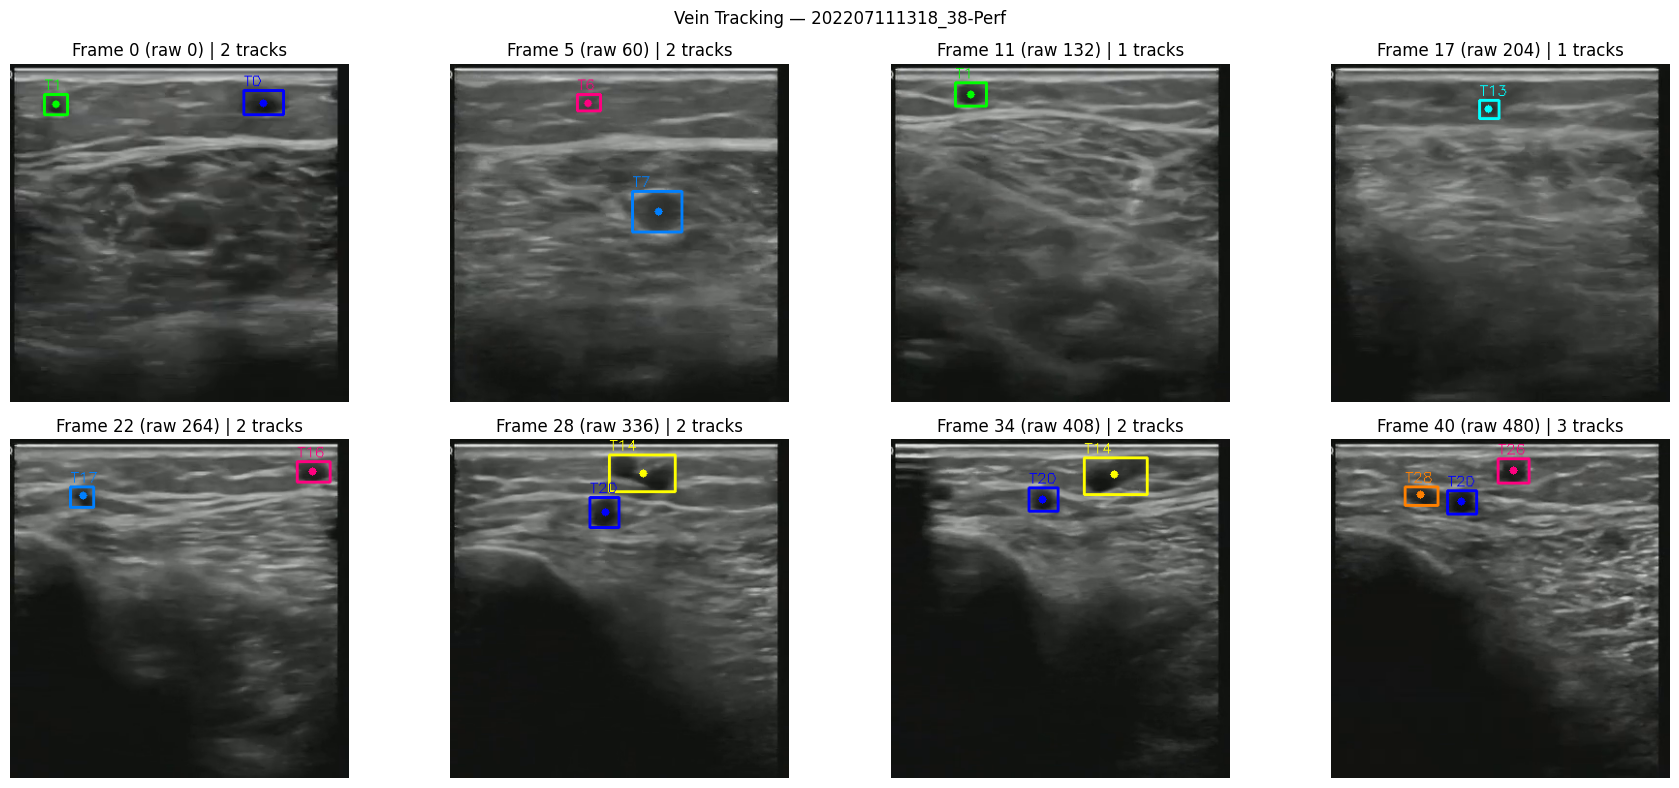

In [16]:
COLORS = [(255,0,0),(0,255,0),(0,0,255),(255,255,0),(0,255,255),
          (255,0,255),(128,0,255),(255,128,0),(0,128,255),(128,255,0)]

def draw_tracks(frame_bgr, records):
    vis = frame_bgr.copy()
    h0, w0 = frame_bgr.shape[:2]
    sx, sy  = w0 / IMG_SIZE, h0 / IMG_SIZE
    for r in records:
        col = COLORS[r['track_id'] % len(COLORS)]
        x, y = int(r['x']*sx), int(r['y']*sy)
        w, h = int(r['w']*sx), int(r['h']*sy)
        cx, cy = int(r['cx']*sx), int(r['cy']*sy)
        cv2.rectangle(vis, (x, y), (x+w, y+h), col, 2)
        cv2.circle(vis, (cx, cy), 4, col, -1)
        cv2.putText(vis, f'T{r["track_id"]}', (x, y-5),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, col, 1)
    return vis

sample_vp = next((vp for vp in sorted(videos)
                  if len(tracks_df[tracks_df['video'] == vp.stem]) > 0), None)

if sample_vp:
    cap  = cv2.VideoCapture(str(sample_vp))
    df_v = tracks_df[tracks_df['video'] == sample_vp.stem]

    # Sample from actual proc_idx range, map to raw frames for seeking
    max_proc = int(df_v['frame_idx'].max()) if len(df_v) else 0
    sample_proc = np.linspace(0, max_proc, 8, dtype=int)

    fig, axes = plt.subplots(2, 4, figsize=(18, 8))
    for ax, fi in zip(axes.flat, sample_proc):
        row_match = df_v[df_v['frame_idx'] == fi]
        raw_fi = int(row_match['raw_frame_idx'].iloc[0]) if len(row_match) else fi * round((cap.get(cv2.CAP_PROP_FPS) or 25) / 5)
        cap.set(cv2.CAP_PROP_POS_FRAMES, raw_fi)
        ret, frame = cap.read()
        if not ret: ax.axis('off'); continue
        recs = row_match.to_dict('records')
        vis  = draw_tracks(frame, recs)
        ax.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
        ax.set_title(f'Frame {fi} (raw {raw_fi}) | {len(recs)} tracks'); ax.axis('off')

    cap.release()
    plt.suptitle(f'Vein Tracking — {sample_vp.stem}', fontsize=12)
    plt.tight_layout()
    plt.savefig(str(PLOT_DIR / 'sample_tracking.png'), dpi=120, bbox_inches='tight')
    plt.show()

  VEIN TRACKING — SUMMARY
  Videos processed  : 5
  Total frames      : 325
  Total unique tracks: 83
  Mean track length : 4.1 frames
  Median track length: 1.0 frames
  Tracks > 10 frames: 9


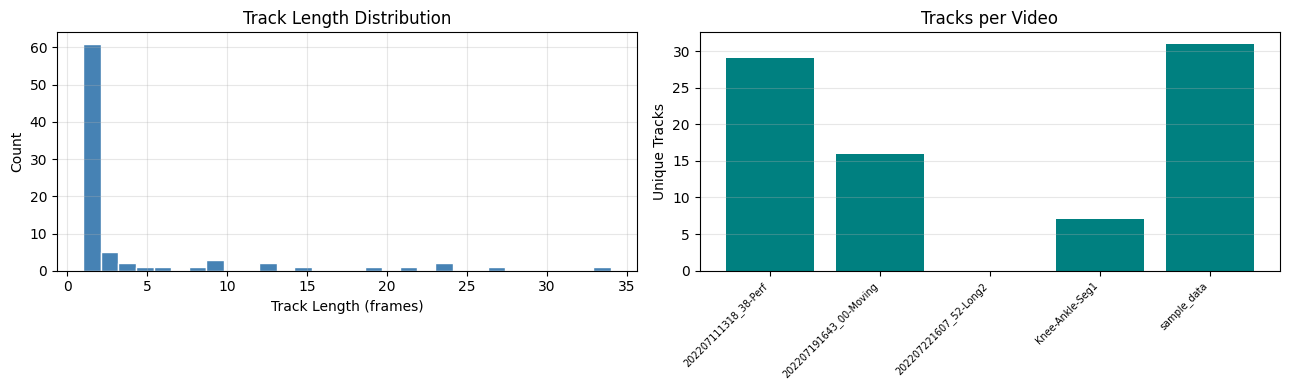

In [17]:
if len(tracks_df):
    track_lens = (tracks_df.groupby(['video', 'track_id'])['frame_idx']
                  .count().reset_index().rename(columns={'frame_idx': 'length'}))

    print('=' * 50)
    print('  VEIN TRACKING — SUMMARY')
    print('=' * 50)
    print(f'  Videos processed  : {summary_df["video"].nunique()}')
    print(f'  Total frames      : {summary_df["n_frames"].sum()}')
    print(f'  Total unique tracks: {len(track_lens)}')
    print(f'  Mean track length : {track_lens["length"].mean():.1f} frames')
    print(f'  Median track length: {track_lens["length"].median():.1f} frames')
    print(f'  Tracks > 10 frames: {(track_lens["length"] > 10).sum()}')
    print('=' * 50)

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    axes[0].hist(track_lens['length'], bins=30, color='steelblue', edgecolor='white')
    axes[0].set_xlabel('Track Length (frames)'); axes[0].set_ylabel('Count')
    axes[0].set_title('Track Length Distribution'); axes[0].grid(True, alpha=0.3)

    pv = summary_df.set_index('video')['n_tracks']
    axes[1].bar(range(len(pv)), pv.values, color='teal')
    axes[1].set_xticks(range(len(pv)))
    axes[1].set_xticklabels(pv.index, rotation=45, ha='right', fontsize=7)
    axes[1].set_ylabel('Unique Tracks'); axes[1].set_title('Tracks per Video')
    axes[1].grid(True, alpha=0.3, axis='y')

    plt.tight_layout()
    plt.savefig(str(PLOT_DIR / 'tracking_stats.png'), dpi=120, bbox_inches='tight')
    plt.show()

**Training a LSTM based motion instead of the algorithmic tracking we have above**

In [18]:
VEIN_META = DATA_ROOT / 'output/vein/metadata.csv'
df_meta   = pd.read_csv(VEIN_META)
df_meta   = df_meta[df_meta['has_vein']].reset_index(drop=True)
df_meta['mask_path'] = df_meta['mask_path'].apply(
    lambda p: str(DATA_ROOT / p) if not p.startswith('/') else p)

SEQ_LEN  = 5
FEAT_DIM = 4  # cx, cy, w, h — all normalised by IMG_SIZE

def mask_to_state(mask_path):
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    if mask is None: return None
    mask = cv2.resize(mask, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_NEAREST)
    n, _, stats, centroids = cv2.connectedComponentsWithStats(
        (mask > 0).astype(np.uint8), connectivity=8)
    if n <= 1: return None
    best = int(np.argmax(stats[1:, cv2.CC_STAT_AREA])) + 1
    return [
        float(centroids[best][0]) / IMG_SIZE,
        float(centroids[best][1]) / IMG_SIZE,
        stats[best, cv2.CC_STAT_WIDTH]  / IMG_SIZE,
        stats[best, cv2.CC_STAT_HEIGHT] / IMG_SIZE,
    ]

sequences, targets = [], []
for video, grp in df_meta.groupby('video'):
    grp    = grp.sort_values('frame_idx').reset_index(drop=True)
    states = [mask_to_state(row['mask_path']) for _, row in grp.iterrows()]
    for i in range(len(states) - SEQ_LEN):
        window = states[i:i+SEQ_LEN+1]
        if any(s is None for s in window): continue
        sequences.append(window[:SEQ_LEN])
        targets.append(window[SEQ_LEN])

X = np.array(sequences, dtype=np.float32)  # (N, SEQ_LEN, 4)
y = np.array(targets,   dtype=np.float32)  # (N, 4)
print(f'Sequences: {len(X)}  shape: {X.shape}')
print(f'cx range: [{X[:,:,0].min():.2f}, {X[:,:,0].max():.2f}]')
print(f'cy range: [{X[:,:,1].min():.2f}, {X[:,:,1].max():.2f}]')

Sequences: 2022  shape: (2022, 5, 4)
cx range: [0.03, 0.93]
cy range: [0.08, 0.57]


Train: 1718  Val: 304


/home/krish/miniconda/lib/python3.13/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
W0000 00:00:1779947395.185901   23888 gpu_kernel_to_blob_pass.cc:190] Failed to compile generated PTX with ptxas. Falling back to compilation by driver.


Model: "vein_motion_lstm"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 5, 64)          │        17,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 5, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4)              │           132 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,212 (118.02 KB)

...

Epoch 1/150


W0000 00:00:1779947396.352560   25123 gpu_kernel_to_blob_pass.cc:190] Failed to compile generated PTX with ptxas. Falling back to compilation by driver.
W0000 00:00:1779947396.353432   25117 gpu_kernel_to_blob_pass.cc:190] Failed to compile generated PTX with ptxas. Falling back to compilation by driver.
W0000 00:00:1779947396.354521   25122 gpu_kernel_to_blob_pass.cc:190] Failed to compile generated PTX with ptxas. Falling back to compilation by driver.
W0000 00:00:1779947396.356085   25114 gpu_kernel_to_blob_pass.cc:190] Failed to compile generated PTX with ptxas. Falling back to compilation by driver.
W0000 00:00:1779947396.357442   25118 gpu_kernel_to_blob_pass.cc:190] Failed to compile generated PTX with ptxas. Falling back to compilation by driver.
W0000 00:00:1779947396.358599   25109 gpu_kernel_to_blob_pass.cc:190] Failed to compile generated PTX with ptxas. Falling back to compilation by driver.
W0000 00:00:1779947396.360140   25110 gpu_kernel_to_blob_pass.cc:190] Failed to co

11/54 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0654 - mae: 0.2068

W0000 00:00:1779947398.061918   24026 gpu_kernel_to_blob_pass.cc:190] Failed to compile generated PTX with ptxas. Falling back to compilation by driver.


53/54 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0344 - mae: 0.1348
Epoch 1: val_loss improved from None to 0.00335, saving model to /home/krish/vein_detection_task_3_training/output/tracking/lstm_motion_predictor.keras

Epoch 1: finished saving model to /home/krish/vein_detection_task_3_training/output/tracking/lstm_motion_predictor.keras
54/54 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - loss: 0.0173 - mae: 0.0913 - val_loss: 0.0033 - val_mae: 0.0393 - learning_rate: 0.0010
Epoch 2/150
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0057 - mae: 0.0548
Epoch 2: val_loss improved from 0.00335 to 0.00187, saving model to /home/krish/vein_detection_task_3_training/output/tracking/lstm_motion_predictor.keras

Epoch 2: finished saving model to /home/krish/vein_detection_task_3_training/output/tracking/lstm_motion_predictor.keras
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0051 - mae: 0.0517 - val_loss: 0.0019 - val_mae: 0.0279 - learning_rate: 0.0010
Epoch 3/150
53/54 ━━━━━━━━━━━━━━━━━━━━ 0

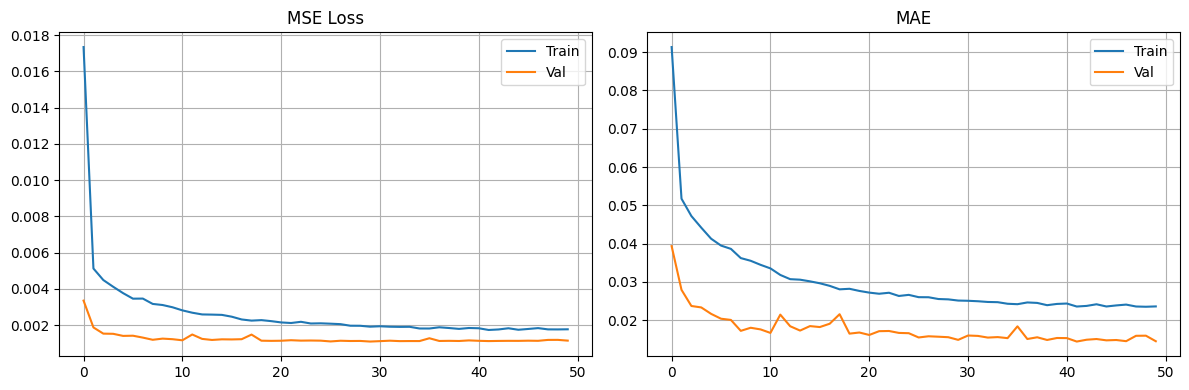

Best val_loss: 0.001089


In [19]:
from sklearn.model_selection import train_test_split

X_tr, X_val, y_tr, y_val = train_test_split(X, y, test_size=0.15, random_state=42)
print(f'Train: {len(X_tr)}  Val: {len(X_val)}')

lstm_model = tf.keras.Sequential([
    tf.keras.layers.LSTM(64, input_shape=(SEQ_LEN, FEAT_DIM), return_sequences=True),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.LSTM(32),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(FEAT_DIM),
], name='vein_motion_lstm')

lstm_model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss='mse',
    metrics=['mae'],
    jit_compile=False
)
lstm_model.summary()

LSTM_CKPT = str(OUT_DIR / 'lstm_motion_predictor.keras')
history_lstm = lstm_model.fit(
    X_tr, y_tr,
    validation_data=(X_val, y_val),
    epochs=150,
    batch_size=32,
    callbacks=[
        tf.keras.callbacks.ModelCheckpoint(
            LSTM_CKPT, monitor='val_loss', save_best_only=True, verbose=1),
        tf.keras.callbacks.EarlyStopping(
            monitor='val_loss', patience=20, restore_best_weights=True, verbose=1),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss', patience=10, factor=0.5, min_lr=1e-5, verbose=1),
    ],
    verbose=1
)

# Training curve
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history_lstm.history['loss'],     label='Train')
axes[0].plot(history_lstm.history['val_loss'], label='Val')
axes[0].set_title('MSE Loss'); axes[0].legend(); axes[0].grid(True)
axes[1].plot(history_lstm.history['mae'],      label='Train')
axes[1].plot(history_lstm.history['val_mae'],  label='Val')
axes[1].set_title('MAE'); axes[1].legend(); axes[1].grid(True)
plt.tight_layout()
plt.savefig(str(PLOT_DIR / 'lstm_training_curves.png'), dpi=120, bbox_inches='tight')
plt.show()
print(f'Best val_loss: {min(history_lstm.history["val_loss"]):.6f}')

In [20]:
class LSTMVeinTracker:
    def __init__(self, lstm_model, seq_len=SEQ_LEN, max_lost=5):
        self.lstm      = lstm_model
        self.seq_len   = seq_len
        self.tracks    = {}
        self.next_id   = 0
        self.max_lost  = max_lost

    def _predict_bboxes(self):
        """Batch LSTM prediction for all tracks with enough history."""
        tids, seqs = [], []
        for tid, t in self.tracks.items():
            if len(t['history']) >= self.seq_len:
                tids.append(tid)
                seqs.append(t['history'][-self.seq_len:])
        predicted = {}
        if seqs:
            preds = self.lstm(np.array(seqs, dtype=np.float32), training=False).numpy()
            for tid, p in zip(tids, preds):
                cx = float(np.clip(p[0], 0, 1)) * IMG_SIZE
                cy = float(np.clip(p[1], 0, 1)) * IMG_SIZE
                w  = float(np.clip(p[2], 0.01, 1)) * IMG_SIZE
                h  = float(np.clip(p[3], 0.01, 1)) * IMG_SIZE
                predicted[tid] = (int(cx - w/2), int(cy - h/2), int(w), int(h))
        return predicted

    def update(self, detections, frame_idx):
        predicted_bboxes = self._predict_bboxes()
        active_ids = sorted(self.tracks.keys())

        # Build prev_dets using LSTM prediction where available
        prev_dets = []
        for tid in active_ids:
            d = dict(self.tracks[tid]['last_det'])
            if tid in predicted_bboxes:
                d = dict(d); d['bbox'] = predicted_bboxes[tid]
            prev_dets.append(d)

        matches, unmatched_curr = match_detections(prev_dets, detections)
        matched_prev = {p for p, _ in matches}

        for p_idx, c_idx in matches:
            tid = active_ids[p_idx]
            det = detections[c_idx]
            cx, cy = det['centroid']
            x, y, w, h = det['bbox']
            self.tracks[tid]['last_det'] = det
            self.tracks[tid]['lost']     = 0
            self.tracks[tid]['age']     += 1
            self.tracks[tid]['history'].append(
                [cx/IMG_SIZE, cy/IMG_SIZE, w/IMG_SIZE, h/IMG_SIZE])

        for i, tid in enumerate(active_ids):
            if i not in matched_prev:
                self.tracks[tid]['lost'] += 1
        self.tracks = {tid: t for tid, t in self.tracks.items()
                       if t['lost'] <= self.max_lost}

        for c_idx in unmatched_curr:
            det = detections[c_idx]
            cx, cy = det['centroid']
            x, y, w, h = det['bbox']
            self.tracks[self.next_id] = {
                'last_det': det, 'lost': 0, 'age': 1,
                'history': [[cx/IMG_SIZE, cy/IMG_SIZE, w/IMG_SIZE, h/IMG_SIZE]],
            }
            self.next_id += 1

        records = []
        for tid, t in self.tracks.items():
            if t['lost'] == 0:
                det = t['last_det']
                x, y, w, h = det['bbox']
                cx, cy = det['centroid']
                records.append({
                    'frame_idx': frame_idx, 'track_id': tid,
                    'cx': round(cx, 2), 'cy': round(cy, 2),
                    'x': x, 'y': y, 'w': w, 'h': h,
                    'area': det['area'], 'age': t['age'],
                })
        return records


def process_video_lstm(video_path, lstm_model, min_det_area=50, max_lost=5, target_fps=5):
    cap     = cv2.VideoCapture(str(video_path))
    src_fps = cap.get(cv2.CAP_PROP_FPS) or 25
    skip    = max(1, round(src_fps / target_fps))
    tracker = LSTMVeinTracker(lstm_model, seq_len=SEQ_LEN, max_lost=max_lost)
    records = []
    raw_idx = 0; proc_idx = 0
    while True:
        ret, frame = cap.read()
        if not ret: break
        if raw_idx % skip == 0:
            mask = predict_mask(frame)
            dets = extract_detections(mask, min_area=min_det_area)
            for r in tracker.update(dets, proc_idx):
                r['video']         = video_path.stem
                r['raw_frame_idx'] = raw_idx
                records.append(r)
            proc_idx += 1
        raw_idx += 1
    cap.release()
    return pd.DataFrame(records), proc_idx

In [21]:
lstm_model = tf.keras.models.load_model(LSTM_CKPT, compile=False)

all_dfs_lstm, summary_lstm = [], []
for vp in sorted(videos):
    t0 = time.time()
    df, n_frames = process_video_lstm(vp, lstm_model)
    elapsed = time.time() - t0
    n_tracks = df['track_id'].nunique() if len(df) else 0
    all_dfs_lstm.append(df)
    summary_lstm.append({'video': vp.stem, 'n_frames': n_frames,
                         'n_tracks': n_tracks, 'elapsed_s': round(elapsed, 1)})
    print(f'{vp.stem}: {n_frames} frames, {n_tracks} tracks, {elapsed:.1f}s')

tracks_lstm_df = pd.concat(all_dfs_lstm, ignore_index=True) if all_dfs_lstm else pd.DataFrame()
tracks_lstm_df.to_csv(OUT_DIR / 'vein_tracks_lstm.csv', index=False)
print(f'\nSaved {len(tracks_lstm_df)} track records')

202207111318_38-Perf: 41 frames, 29 tracks, 5.9s
202207191643_00-Moving: 123 frames, 24 tracks, 14.8s
202207221607_52-Long2: 10 frames, 0 tracks, 1.3s
Knee-Ankle-Seg1: 71 frames, 9 tracks, 10.8s
sample_data: 80 frames, 38 tracks, 11.4s

Saved 339 track records


       IoU Tracker    |    LSTM Tracker
  Total tracks :     83        |     100
  Mean length  :    4.1        |     3.4
  Tracks > 5f  :     14        |      19
  Tracks > 10f :      9        |       4


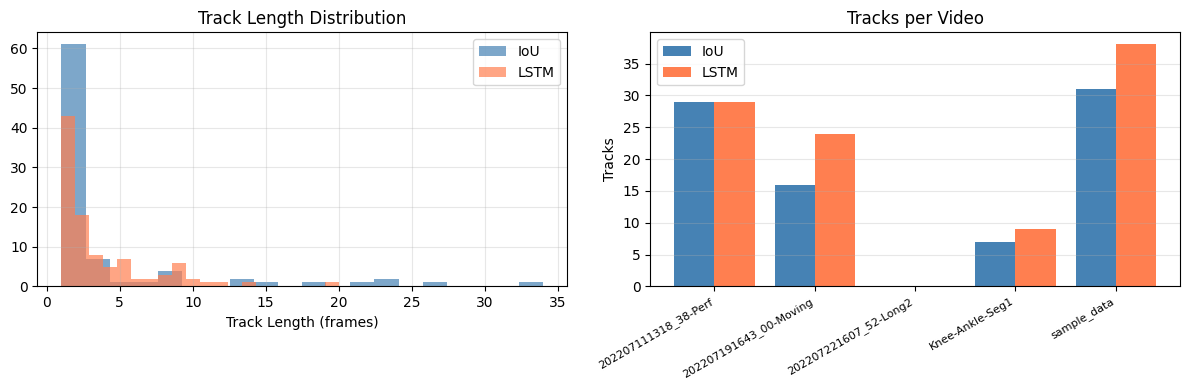

In [22]:
summary_iou  = pd.read_csv(OUT_DIR / 'tracking_summary.csv')
summary_lstm_df = pd.DataFrame(summary_lstm)

tl_iou  = tracks_df.groupby(['video','track_id'])['frame_idx'].count().reset_index()
tl_lstm = tracks_lstm_df.groupby(['video','track_id'])['frame_idx'].count().reset_index()

print('='*52)
print('       IoU Tracker    |    LSTM Tracker')
print('='*52)
print(f'  Total tracks : {len(tl_iou):>6}        |  {len(tl_lstm):>6}')
print(f'  Mean length  : {tl_iou["frame_idx"].mean():>6.1f}        |  {tl_lstm["frame_idx"].mean():>6.1f}')
print(f'  Tracks > 5f  : {(tl_iou["frame_idx"]>5).sum():>6}        |  {(tl_lstm["frame_idx"]>5).sum():>6}')
print(f'  Tracks > 10f : {(tl_iou["frame_idx"]>10).sum():>6}        |  {(tl_lstm["frame_idx"]>10).sum():>6}')
print('='*52)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(tl_iou['frame_idx'],  bins=20, alpha=0.7, label='IoU',  color='steelblue')
axes[0].hist(tl_lstm['frame_idx'], bins=20, alpha=0.7, label='LSTM', color='coral')
axes[0].set_xlabel('Track Length (frames)'); axes[0].set_title('Track Length Distribution')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

per_iou  = summary_iou.set_index('video')['n_tracks']
per_lstm = summary_lstm_df.set_index('video')['n_tracks']
x = np.arange(len(per_iou))
axes[1].bar(x - 0.2, per_iou.values,  0.4, label='IoU',  color='steelblue')
axes[1].bar(x + 0.2, per_lstm.reindex(per_iou.index).values, 0.4, label='LSTM', color='coral')
axes[1].set_xticks(x); axes[1].set_xticklabels(per_iou.index, rotation=30, ha='right', fontsize=8)
axes[1].set_ylabel('Tracks'); axes[1].set_title('Tracks per Video'); axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(str(PLOT_DIR / 'tracker_comparison.png'), dpi=120, bbox_inches='tight')
plt.show()